# Comparing Variants of BAF

##Техническая часть


In [2]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

%pip install opendatasets

import opendatasets as od
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
SEED = 1208
np.random.seed(SEED)

##Загрузим датасет

In [5]:
#upload dataset from kaggle
cwd = os.getcwd()

od.download("https://www.kaggle.com/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022/data", path=cwd, force=True)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: c
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/sgpjesus/bank-account-fraud-dataset-neurips-2022


100%|██████████| 532M/532M [00:09<00:00, 59.3MB/s]


In [7]:
variants = {
    'Base': 'Base.csv',
    'Variant I':   'Variant I.csv',
    'Variant II':  'Variant II.csv',
    'Variant III': 'Variant III.csv',
    'Variant IV':  'Variant IV.csv',
    'Variant V':   'Variant V.csv'
}

summary = []
for name, fname in variants.items():
    df = pd.read_csv(f'/content/bank-account-fraud-dataset-neurips-2022/{fname}')
    summary.append({
        'Variant':    name,
        'N':          len(df),
        'Fraud rate': df['fraud_bool'].mean(),
        'credit_risk_score mean': df['credit_risk_score'].mean(),
        'velocity_6h mean':       df['velocity_6h'].mean(),
        'zip_count_4w mean':      df['zip_count_4w'].mean(),
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

    Variant       N  Fraud rate  credit_risk_score mean  velocity_6h mean  zip_count_4w mean
       Base 1000000    0.011029              130.989595       5665.296605        1572.692049
  Variant I 1000000    0.011029              129.414278       5661.914760        1574.468789
 Variant II 1000000    0.011029              137.458152       5685.095489        1567.400554
Variant III 1000000    0.011030              139.291954       5489.726431        1517.657134
 Variant IV 1000000    0.011030              139.297788       5489.687702        1517.545997
  Variant V 1000000    0.011030              139.295998       5490.939853        1517.471615


далее - визуализация дрейфа. посмотрим чем отличаются распределения ключевых признаков

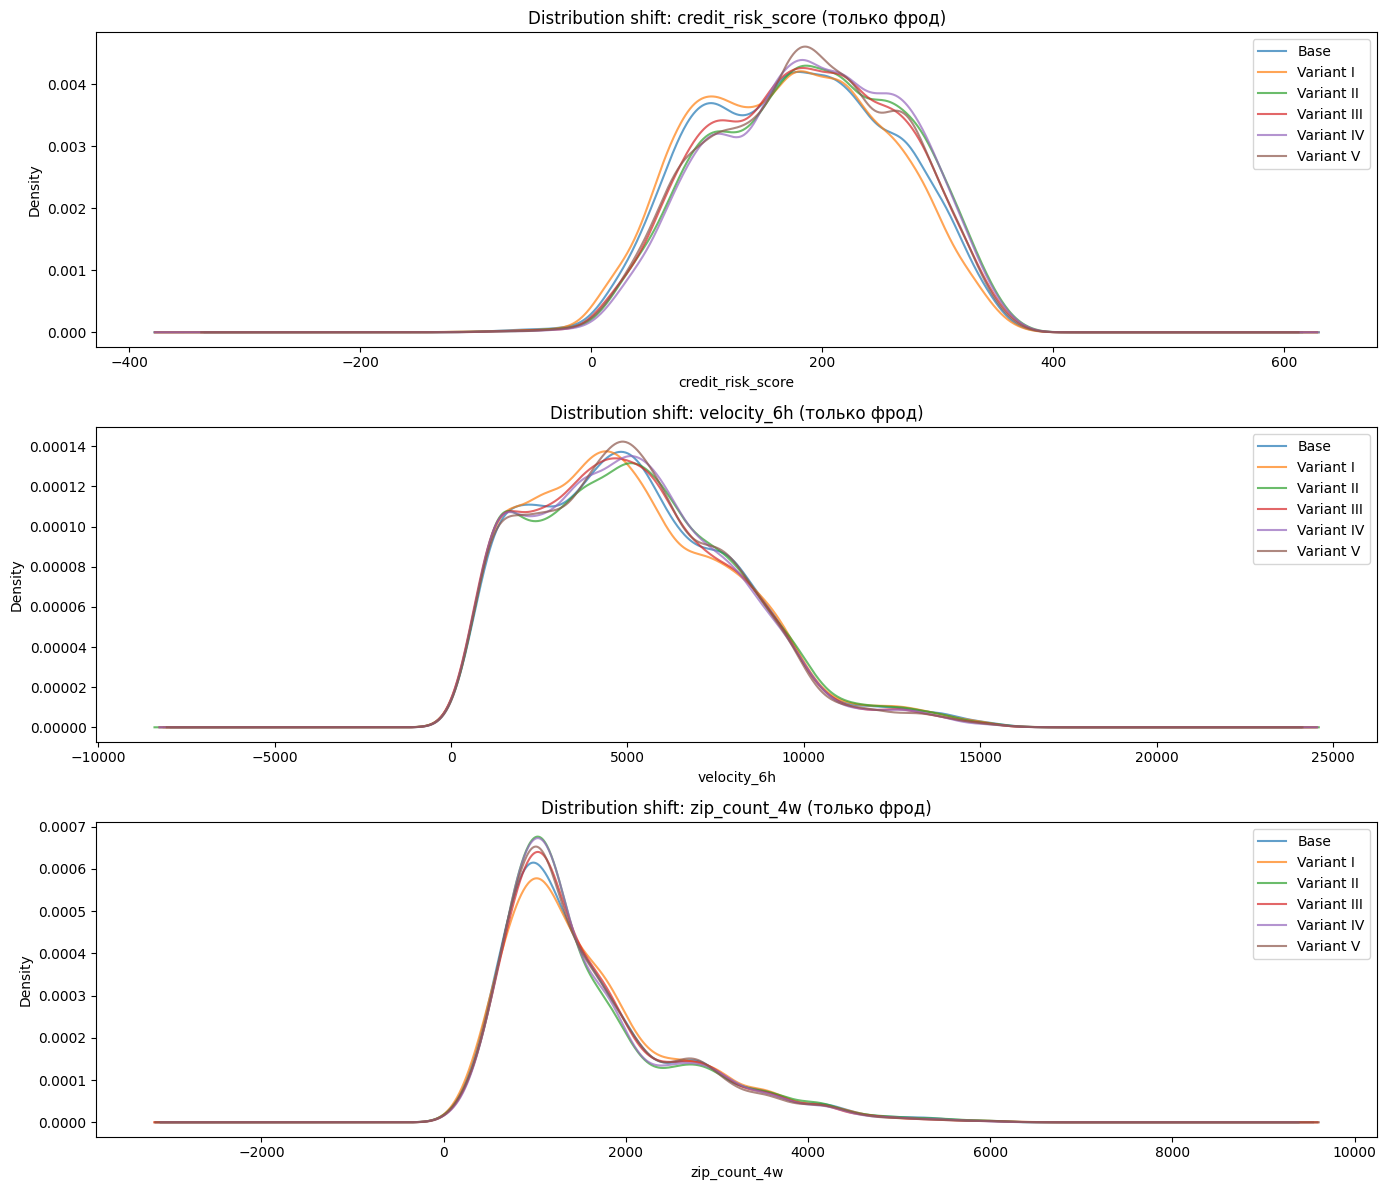

In [9]:
key_features = ['credit_risk_score', 'velocity_6h', 'zip_count_4w']

fig, axes = plt.subplots(len(key_features), 1, figsize=(14, 4 * len(key_features)))

for ax, feat in zip(axes, key_features):
    for name, fname in variants.items():
        df = pd.read_csv(f'/content/bank-account-fraud-dataset-neurips-2022/{fname}')
        fraud_only = df[df['fraud_bool'] == 1][feat].dropna()
        fraud_only.plot(kind='kde', ax=ax, label=name, alpha=0.7)
    ax.set_title(f'Distribution shift: {feat} (только фрод)')
    ax.legend()
    ax.set_xlabel(feat)

plt.tight_layout()
plt.show()

Метрика сдвига — насколько далеко каждый Variant от Base статистически. Для этого удобен Population Stability Index (PSI) — он стандартен в банковской аналитике

In [11]:
def calc_psi(base, variant, bins=10):
    breakpoints = np.linspace(
        min(base.min(), variant.min()),
        max(base.max(), variant.max()),
        bins + 1
    )
    base_pct    = np.histogram(base,    bins=breakpoints)[0] / len(base)
    variant_pct = np.histogram(variant, bins=breakpoints)[0] / len(variant)

    # избегаем деления на ноль
    base_pct    = np.where(base_pct    == 0, 1e-6, base_pct)
    variant_pct = np.where(variant_pct == 0, 1e-6, variant_pct)

    return np.sum((variant_pct - base_pct) * np.log(variant_pct / base_pct))

# считаем PSI для каждого признака и каждого варианта
base_df = pd.read_csv('/content/bank-account-fraud-dataset-neurips-2022/Base.csv')
psi_results = []

for name, fname in list(variants.items())[1:]:  # пропускаем Base
    df = pd.read_csv(f'/content/bank-account-fraud-dataset-neurips-2022/{fname}')
    for feat in key_features:
        psi = calc_psi(
            base_df[feat].dropna(),
            df[feat].dropna()
        )
        psi_results.append({'Variant': name, 'Feature': feat, 'PSI': round(psi, 4)})

psi_df = pd.DataFrame(psi_results).pivot(index='Variant', columns='Feature', values='PSI')
print(psi_df)
# PSI < 0.1  — сдвига нет
# PSI 0.1–0.2 — умеренный сдвиг
# PSI > 0.2  — значительный сдвиг

Feature      credit_risk_score  velocity_6h  zip_count_4w
Variant                                                  
Variant I               0.0006       0.0001        0.0002
Variant II              0.0090       0.0011        0.0040
Variant III             0.0137       0.0048        0.0079
Variant IV              0.0137       0.0048        0.0079
Variant V               0.0137       0.0048        0.0077
